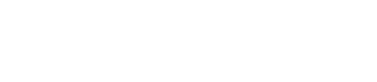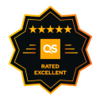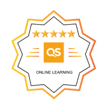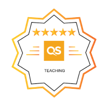

# Machine Learning I · Sesión 1 · Qué aprende una máquina

**Universidad EAN · Facultad de Ingeniería · Posgrado**

*Profesor:* Jaime Alberto Ochoa Durán

*Profesor en Inteligencia Artificial · Facultad de Ingeniería*

🔗 [LinkedIn · jaimeochoa-manager](https://www.linkedin.com/in/jaimeochoa-manager/)

## Trazabilidad de la sesión · Session traceability

| Campo | Valor |
|---|---|
| Unidad y código | Machine Learning I · IMVN0004 |
| Programa y modalidad | Especialización en Machine Learning · Maestría en Ciencia de Datos · Maestría en Gerencia en Inteligencia Artificial · Presencial |
| Módulo · Sesión | M1, Fundamentos, metodología y preparación · Sesión 1 de 18 |
| Hilo conductor | Fórmula 1: familias de motores y fin de semana de carrera |
| Conjunto de datos | Extracto 2019 de siniestros viales de Bogotá, 32 962 filas (Secretaría Distrital de Movilidad, 2021) |
| Fase CRISP-DM | Comprensión del negocio |
| Resultado de aprendizaje | Clasificar un problema de negocio en su paradigma y su fase de CRISP-DM |
| Evidencia | Reto acumulativo R1 |
| Nivel cognitivo | Comprender |
| Tiempo | 50 min de ejecución guiada · Reto R1: 2,25 h autónomas |
| Lenguaje y versión | Python 3.11 · pandas, numpy |


## Cómo se trabaja este cuaderno · How to work this notebook

1. Responda cada 🎯 y cada 🔮 **antes** de abrir la solución plegada. Abrirla primero convierte el ejercicio en lectura, no en práctica.
2. Ejecute las celdas en orden. Varias secciones dependen del estado que deja la anterior, igual que las 18 sesiones de la unidad dependen unas de otras.
3. Si algo genera un error que el enunciado no anticipó, revise primero el orden de ejecución de las celdas antes de reportarlo: es la causa más frecuente.

## Estructura del cuaderno · Notebook structure

| # | Sección | Marca dominante |
|---|---|---|
| 1 | Cargar el extracto y mirarlo sin tocarlo | 🔮 Predice antes de ejecutar |
| 2 | Separar identificadores de variables reales | 🕵️ Error silencioso 1 |
| 3 | Formular el problema como aprendizaje supervisado | 🧪 Riesgo empírico de una regla base |
| 4 | Formular el problema como aprendizaje no supervisado | 🕵️ Error silencioso 2 |
| 5 | Anatomía completa de un problema de machine learning | 🌐 Exercise in English · 🩺 Depuración guiada |
| 6 | CRISP-DM: dónde estamos y hacia dónde vamos | 💼 Reto de Negocio de cierre |


## Marcas del cuaderno · Notebook marks

| Marca | Significado |
|---|---|
| 🔁 Repaso | Tres preguntas de la sección anterior |
| 🌱 Analogía | Explicación desde el mundo físico o administrativo, con su límite declarado |
| 🔬 Nota técnica | Profundidad adicional para quien ya programa |
| ⚠️ Error frecuente | El error ruidoso, el que Python reporta |
| 🕵️ Error silencioso | Código que no falla y produce un resultado plausible y falso |
| 🔮 Predice antes de ejecutar | Anticipar el resultado antes de correr la celda |
| 🎯 Ejercicio rápido | Pregunta de discriminación, sin código |
| 🧪 Autocomprobación | Código con verificador sellado |
| 🩺 Depuración guiada | Corregir un error provocado, bajo una restricción |
| 🌐 Exercise in English | Enunciado y respuesta íntegramente en inglés |
| 🛠️ Retos técnicos | Tres niveles: 🟢 guiado, 🟡 aplicado, 🔴 autónomo |
| 💼 Reto de Negocio | Decisión profesional sin código, cinco puntos |
| ✍️ Interpretación | Celda editable para responder el reto de negocio |
| 📚 Referencias | Fuentes APA 7 de la sección |


## Antes de empezar, sus datos · Before you start, your data

Este cuaderno no trae los datos incrustados en el código: vienen aparte, en `ML1_S01_laboratorio_practico_v1.zip`, la carpeta de esta sesión, para que sea transparente de dónde salen y cómo se llega al recorte que se usa en clase.

1. Descomprima `ML1_S01_laboratorio_practico_v1.zip`. Va a encontrar este cuaderno y el archivo `historico_siniestros_bogota.csv`, el conjunto completo tal como la docencia lo descargó y verificó el 2026-09-20.
2. Suba la carpeta descomprimida a su Google Drive, en cualquier ubicación. No importa el nombre de la carpeta ni en qué parte de su Drive quede: el cuaderno busca el archivo por su nombre exacto. Lo único que no debe cambiar es el nombre del archivo `historico_siniestros_bogota.csv`.
3. Antes de correr la celda de preparación del entorno, intente primero la descarga directa desde el portal oficial: la celda ya lo hace por usted, y solo si esa descarga falla monta su Google Drive y busca el archivo que subió. Vivir ambos caminos, el de la fuente en vivo y el del respaldo, es parte de la experiencia de esta sesión.

## Preparación del entorno · Environment setup

La celda intenta primero descargar el conjunto completo directamente desde el portal oficial. Si esa descarga falla, por política CORS, caída del portal o límite de la fuente, monta Google Drive y lee el archivo que la docencia ya descargó y verificó. Ninguno de los dos caminos filtra ni limpia nada todavía: eso es contenido visible de la Sección 1.

In [ ]:
import glob
import numpy as np
import pandas as pd

SEMILLA = 2026
np.random.seed(SEMILLA)

URL_FUENTE = (
    "https://datosabiertos.bogota.gov.co/dataset/8624f916-1db2-4c17-b669-19a19b35d1ca/"
    "resource/f5862aaa-4e1c-463e-94d5-f04db8164360/download/"
    "historico_siniestros_bogota_d.c_-.csv"
)
NOMBRE_ARCHIVO_RESPALDO = "historico_siniestros_bogota.csv"
FECHA_VERIFICACION_DOCENCIA = "2026-09-20"

try:
    crashes_full = pd.read_csv(URL_FUENTE)
    print(f"Descarga directa desde la fuente oficial: {len(crashes_full)} filas.")
except Exception as e:
    print(f"Descarga directa no disponible ({type(e).__name__}).")
    from google.colab import drive
    drive.mount("/content/drive")

    # busqueda por nombre de archivo, sin asumir en que carpeta de Drive quedo:
    # funciona sin importar donde ni con que nombre de carpeta se subio el .zip descomprimido
    _coincidencias = glob.glob(
        f"/content/drive/MyDrive/**/{NOMBRE_ARCHIVO_RESPALDO}", recursive=True
    )
    if not _coincidencias:
        raise FileNotFoundError(
            f"No se encontro '{NOMBRE_ARCHIVO_RESPALDO}' en su Google Drive. "
            "Verifique que subio la carpeta descomprimida de "
            "ML1_S01_laboratorio_practico_v1.zip a su Drive, en cualquier ubicacion."
        )
    RUTA_DRIVE = _coincidencias[0]
    print(f"Archivo encontrado en: {RUTA_DRIVE}")
    crashes_full = pd.read_csv(RUTA_DRIVE)
    print(
        f"Se usa el archivo verificado por la docencia el {FECHA_VERIFICACION_DOCENCIA}: "
        f"{len(crashes_full)} filas."
    )

## 1. Cargar el extracto y mirarlo sin tocarlo · Loading the extract without touching it

**Al terminar esta sección podrás:**
1. Cargar un conjunto de datos reales y aplicar, de forma visible y justificada, el recorte que la sesión necesita.
2. Describir su forma, sus tipos y sus primeras filas.
3. Anticipar, antes de ejecutar, cuál de dos maneras de inspeccionar un DataFrame revela más información.
4. **Juzgar** si un conjunto de datos, tal como llega, ya está listo para responder una pregunta de negocio.


Un resultado que parece confirmar la hipótesis puede estar confirmando, en cambio, que el planteamiento del problema estaba mal armado desde el principio. Esa es la tesis de este cuaderno, y esta primera sección solo la insinúa: todavía no hay hipótesis que confirmar, apenas datos que mirar sin tocar.

### 1.1 Por qué el año 2019

Un conjunto de datos abiertos multianual casi nunca es homogéneo entre años. Cambios en el proceso de reporte, en la cobertura de las cámaras y patrullas que registran cada siniestro, o en la actividad misma que se mide, hacen que un año no sea intercambiable con otro. Por eso la primera decisión de este cuaderno no es de modelado sino de **alcance temporal**: sobre qué período se va a trabajar, y esa decisión se toma mirando los datos, no adivinando.

Trabajar los siete años del conjunto oficial a la vez excede el tamaño manejable para una sesión de práctica, así que el módulo fija un solo año. La pregunta que abre esta subsección es, entonces, cuál de los siete conviene, y la respuesta depende de un criterio explícito, no de tomar el primero o el más reciente sin mirar. Ese criterio, y el recorte que produce, se hacen aquí, a la vista, no en un archivo aparte que nadie revisa: es la primera aplicación de la regla de esta unidad de que ningún filtrado ocurre fuera del cuaderno.

In [ ]:
print("Filas totales, 2015 a 2021:", crashes_full.shape[0])
print(crashes_full["ANO_OCURRENCIA_ACC"].value_counts().sort_index())

Se fija **2019**: es el año con más registros antes de la caída de movilidad por la pandemia en 2020, así que conserva un patrón estacional genuino de un año completo sin esa distorsión. Fíjese en el conteo por año que acaba de imprimir: 2020 y 2021 caen de forma abrupta, no porque hubiera menos siniestros, sino porque hubo menos movilidad y, probablemente, menos reporte. Un año con esa anomalía habría distorsionado cualquier patrón estacional que este módulo quisiera enseñar a reconocer.

In [ ]:
crashes = crashes_full[crashes_full["ANO_OCURRENCIA_ACC"] == 2019].copy()
print("Filas del extracto 2019:", len(crashes))

### 1.2 Qué trae el extracto

`crashes` es el conjunto que el resto de esta sesión, y las Sesiones 2, 3 y 4, van a seguir usando: lo que una sesión deja, la siguiente lo recoge, y por eso conviene conocerlo bien desde ahora.

En CRISP-DM, la fase de **comprensión de los datos** (*data understanding*) es anterior y distinta a la de **preparación de los datos** (*data preparation*): antes de decidir qué transformar, hace falta describir qué se tiene, sin alterarlo. Saltarse ese paso, y pasar directo a limpiar, es una forma frecuente de arrastrar un supuesto equivocado hasta el final del proyecto, porque nadie verificó a tiempo si ese supuesto era cierto. La primera pregunta de un proyecto real no es «¿cómo arreglo esto?» sino «¿qué es esto, exactamente?», y esta subsección se queda deliberadamente en esa segunda pregunta.

In [ ]:
print("Filas:", crashes.shape[0])
print("Columnas:", crashes.shape[1])
crashes.head(3)

La sesión no limpia nada todavía, y el resultado lo confirma: hay columnas con nombres que sugieren identificadores administrativos, columnas de fecha sin un formato aún verificado y columnas categóricas en español y en mayúsculas. Nada de eso se toca en esta subsección; se toca, con criterio explícito, en las que siguen.

#### 🌱 Analogía · El inventario antes de la carrera

Antes de decidir el reglaje del auto, el equipo de F1 hace inventario de lo que trae al circuito: neumáticos, alerones, sensores. No modifica nada todavía, solo confirma qué hay. **Dónde se rompe:** un inventario de piezas es finito y se cuenta en minutos; un inventario de datos reales, con dieciséis columnas y casi treinta y tres mil filas, exige herramientas de resumen estadístico, no un conteo manual.

### 1.3 Dos maneras de resumir un DataFrame

`pandas` ofrece dos métodos de resumen que se confunden con frecuencia porque ambos describen «el DataFrame completo» a primera vista, pero cada uno describe una dimensión distinta de la tabla.

`.info()` recorre **columnas** y reporta, para cada una, su tipo de dato (`dtype`) y su número de valores no nulos. Es un resumen de **estructura**: qué hay y de qué forma, sin decir nada sobre la magnitud de los valores. `.describe()`, en cambio, recorre columnas **numéricas** y calcula, para cada una, estadísticos como la media, la desviación estándar y los cuartiles. Es un resumen de **distribución**: cómo se reparten los valores de las columnas que sí admiten aritmética.

La distinción importa porque `.describe()` toma una decisión silenciosa sobre qué incluir y qué dejar fuera, basada en el tipo de dato de cada columna, y esa decisión no se anuncia en ningún mensaje. Confundir ambos métodos, o asumir que `.describe()` resume «todo», es un error frecuente de quien recién empieza.

### 🔮 Predice antes de ejecutar 1

Sin ejecutar la siguiente celda: ¿`crashes.describe()` va a incluir la columna `GRAVEDAD` en su resultado? Responda antes de correr la celda.

In [ ]:
crashes.describe()

<details><summary>Ver la explicación</summary>

No la incluye. `describe()` opera por defecto solo sobre columnas numéricas, y `GRAVEDAD` es de tipo texto (`object`), así que queda fuera del resumen sin que aparezca ningún aviso ni mensaje de advertencia: la tabla resultante simplemente no la menciona, como si no existiera. Para ver un resumen de las columnas de texto hay que pedirlo de forma explícita con `crashes.describe(include='object')`, que calcula estadísticos distintos, propios de datos categóricos: la cantidad de valores únicos, el valor más frecuente y su frecuencia.

El punto de fondo, más allá de `GRAVEDAD`, es que un método que cambia de comportamiento según el tipo de dato de entrada, sin avisarlo en su nombre ni en un mensaje al ejecutarse, es una fuente frecuente de sorpresas silenciosas. Si en un proyecto real `GRAVEDAD` fuera precisamente la variable que se quiere predecir, y alguien corriera `.describe()` esperando un resumen completo del DataFrame, podría cerrar la exploración sin haber mirado ni una sola vez la variable objetivo. La lección práctica es revisar siempre qué columnas aparecen efectivamente en la salida de un resumen antes de asumir que cubre todo lo que hay.
</details>

### 🎯 Ejercicio rápido 1

`crashes.info()` y `crashes.describe()` reportan el mismo número de filas para `LOCALIDAD`, pero por razones distintas. ¿Por qué el número que reporta `.info()` como «non-null» para `LOCALIDAD` no es 32 962?

<details><summary>Ver la solución</summary>

Porque `LOCALIDAD` tiene 2 filas con valor faltante, ya verificadas en la ficha del conjunto de datos del módulo, y `.info()` no cuenta el total de filas de la tabla: cuenta, columna por columna, cuántas de esas filas tienen un valor presente. Esa es la razón por la que la columna se llama, en el propio resumen de `pandas`, «non-null count» y no simplemente «count»: el nombre ya está declarando que lo que se reporta es un conteo condicionado, no el tamaño de la tabla.

La consecuencia práctica es que cualquier columna con al menos un valor faltante muestra, en `.info()`, un número menor al total de filas del DataFrame, y esa diferencia es exactamente la cantidad de faltantes de esa columna. Si `LOCALIDAD` reportara 32 962 «non-null», eso significaría que no le falta ni un solo valor; si reporta 32 960, como es el caso, esos dos valores ausentes están ahí, aunque ninguna celda haya lanzado un error ni un mensaje de advertencia al cargarlos.

Vale la pena notar por qué este ejercicio importa más allá de esta columna en particular. Si esa diferencia pasara inadvertida, alguien podría creer que el conjunto no tiene faltantes en absoluto, simplemente porque nunca comparó el «non-null count» de cada columna contra el número total de filas del DataFrame. Ese hábito de comparación, mirar `.info()` columna por columna y contrastarlo contra `.shape[0]`, es la primera defensa contra un faltante que pasa desapercibido durante toda una exploración.
</details>

### 🧪 Autocomprobación 1

Calcule en `resultado` cuántas columnas del extracto son de tipo `object` (texto). Use `crashes.dtypes`.

In [ ]:
resultado = int((crashes.dtypes == 'object').sum())

# --- No modifiques nada por debajo de esta línea ----------------------
_ref = int((crashes.dtypes == "object").sum())
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que estes contando sobre crashes.dtypes, no sobre crashes.columns.")
else:
    print(f"\u2705 Correcto. Hay {_ref} columnas de tipo object.")

### 🛠️ Retos técnicos 1

🟢 **Nivel 1, guiado.** Muestre las últimas 3 filas del extracto con `.tail(3)`.

*Criterio de logro:* el resultado tiene exactamente 3 filas.

In [ ]:
crashes.tail(3)



🟡 **Nivel 2, aplicado.** Obtenga la lista de nombres de columna cuyo tipo es `float64`.

*Criterio de logro:* la lista tiene exactamente 6 elementos.

In [ ]:
columnas_float = crashes.select_dtypes(include='float64').columns.tolist()
print(columnas_float)



🔴 **Nivel 3, autónomo.** Decida si `ANO_OCURRENCIA_ACC`, de tipo `int64`, debería tratarse como una variable numérica o como una variable categórica en un futuro modelo, y nombre la condición que cambiaría su respuesta.

*Criterio de logro:* la respuesta nombra explícitamente qué haría cambiar de opinión, por ejemplo, tener más de un año disponible en los datos.

📚 Recurso de profundización: McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61.

In [ ]:
# En 2019 el año es constante y no aporta información: lo excluiría.
# Si se incorporan varios años, lo trataría como categoría para evitar asumir una relación lineal.



### 💼 Reto de Negocio 1

La Secretaría Distrital de Movilidad recibe presión de la ciudadanía para anunciar, esta misma semana, en qué localidades va a invertir en reductores de velocidad. El equipo de datos apenas terminó de cargar el extracto de 2019.

**Decisión principal.** ¿Se anuncia una lista de localidades ya, basada en un vistazo rápido a `.head()`, o se pide una semana más para un análisis completo?

**Quién resulta perjudicado.** Si se anuncia ya y el vistazo rápido estaba sesgado, las localidades con más siniestros reales pero menos visibilidad mediática quedan sin intervención. Si se espera, las localidades que sí necesitan la intervención pierden una semana de exposición.

**Indicador y por qué no el obvio.** El número total de siniestros por localidad parece el indicador obvio, pero no pondera por población ni por kilómetros de vía, así que puede favorecer a las localidades más grandes sin que sean las más peligrosas por trayecto.

**Objeción externa.** Un concejal podría objetar que un mes de retraso cuesta vidas. La respuesta: un anuncio basado en un vistazo de tres filas puede dirigir la inversión al lugar equivocado, lo que también cuesta vidas, solo que en otro lugar.

**Límite del análisis.** El extracto de 2019 no dice nada sobre la infraestructura vial actual, así que ninguna decisión de dónde instalar algo hoy puede basarse solo en él.

Fase de CRISP-DM: comprensión del negocio, donde se define qué pregunta responde el proyecto antes de tocar los datos (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 1

*(Doble clic para editar.)*

**Mi decisión:** Pediré una semana para analizar el extracto completo antes de anunciar localidades.

**Quién queda perjudicado si me equivoco:** Residentes de zonas de alto riesgo quedarían sin intervención si el anuncio se sesga.

**Indicador que usaría y por qué no el obvio:** Usaría siniestros graves por exposición vial y población, no solo el conteo total, que favorece localidades más grandes.

**Cómo respondo a la objeción del concejal:** Al concejal le explicaría que una semana de análisis evita asignar recursos al lugar equivocado y entregaría un cronograma concreto.

**Qué no puedo saber con este análisis:** Los datos de 2019 no describen la infraestructura actual.

### 📚 Referencias de la sección 1

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61.

Secretaría Distrital de Movilidad. (2021). *Historico Siniestros Bogotá D.C* [Conjunto de datos]. Datos Abiertos Bogotá. Recuperado el 20 de septiembre de 2026, de https://datosabiertos.bogota.gov.co/dataset/historico-siniestros-bogota-d-c

## 2. Separar identificadores de variables reales · Telling identifiers from real variables

**Al terminar esta sección podrás:**
1. Reconocer una columna identificadora verificando que su número de valores únicos iguala el número de filas.
2. Distinguir entre una columna numérica y una columna que solo *parece* numérica.
3. Explicar por qué un identificador no generaliza a datos nuevos.
4. **Diseñar** un criterio de exclusión de columnas antes de construir cualquier modelo.


### 🔁 Repaso

1. ¿Qué diferencia hay entre lo que resume `.info()` y lo que resume `.describe()`?
2. ¿Por qué `.info()` reportó menos de 32 962 valores no nulos para `LOCALIDAD`?
3. ¿Cuál es la tesis de este cuaderno, en una frase?

<details><summary>Ver las respuestas</summary>

1. `.info()` resume tipos de dato y conteo de valores no nulos por columna; `.describe()` resume estadísticos, como media y desviación, solo de las columnas numéricas por defecto.
2. Porque `LOCALIDAD` tiene 2 filas con valor faltante en el extracto de 2019.
3. Un resultado que parece confirmar la hipótesis puede estar confirmando, en cambio, que el planteamiento del problema estaba mal armado desde el principio.
</details>

### 2.1 Qué es, exactamente, un identificador

Un identificador es una columna cuyo único propósito es distinguir una fila de otra: no describe el fenómeno, describe el registro. `OBJECTID` no dice nada sobre cómo ocurrió un siniestro; solo dice que ese siniestro es distinto del anterior en la tabla. Esa diferencia, entre describir el fenómeno y solo nombrar el registro, es la que separa una variable predictora de una columna que, aunque tenga números o texto, no aporta señal alguna sobre el problema.

La prueba para detectarlo es sencilla y se puede aplicar mecánicamente a cualquier columna: si el número de valores únicos es igual al número de filas, esa columna no puede repetir ningún valor, y una columna que nunca repite valor no puede agrupar nada. Un modelo que aprende sobre una columna así no aprende un patrón generalizable, porque no hay ningún par de filas que compartan valor de entrada del que extraer una regularidad; en el mejor de los casos, memoriza una tabla de correspondencias uno a uno entre el identificador y la etiqueta, que es exactamente lo que se va a comprobar en el error silencioso de esta sección.

In [ ]:
for col in ["OBJECTID", "FORMULARIO", "CODIGO_ACCIDENTE"]:
    print(f"{col:<20}{crashes[col].nunique():>8} valores unicos de {len(crashes)} filas")

Las tres columnas tienen exactamente tantos valores únicos como filas tiene el extracto: son identificadores, no observaciones del fenómeno de siniestralidad.

#### ⚠️ Error frecuente

Escribir el nombre de una columna con una mayúscula distinta a la real produce un error ruidoso e inmediato:

In [ ]:
crashes["Objectid"].head()

Python detiene la ejecución con un `KeyError` y señala exactamente qué nombre no encontró. Es un error incómodo, pero honesto: nadie avanza con datos equivocados sin saberlo. El error de la siguiente subsección es exactamente lo contrario.

### 🕵️ Error silencioso 1

Una manera habitual, y aparentemente razonable, de elegir columnas candidatas a predictoras es pedir todas las numéricas:

In [ ]:
numeric_cols = crashes.select_dtypes(include="number").columns.tolist()
print(numeric_cols)

La celda no falla. La lista incluye `OBJECTID` y `CODIGO_ACCIDENTE`, dos identificadores, junto a columnas que sí describen el siniestro, como `LATITUD` o `CIV`. Nada en el código avisa del error: `select_dtypes` hizo exactamente lo que se le pidió.

Para ver por qué esto es grave y no solo desprolijo, se simula qué pasaría si un modelo usara `CODIGO_ACCIDENTE` como si fuera un predictor legítimo: memorizar un diccionario de código a gravedad sobre un 80 % de las filas, y consultarlo sobre el 20 % restante.

In [ ]:
rng = np.random.default_rng(SEMILLA)
indices = rng.permutation(len(crashes))
n_train = int(len(crashes) * 0.8)
train = crashes.iloc[indices[:n_train]]
reserva = crashes.iloc[indices[n_train:]]

diccionario = dict(zip(train["CODIGO_ACCIDENTE"], train["GRAVEDAD"]))

pred_train = train["CODIGO_ACCIDENTE"].map(diccionario)
exactitud_train = (pred_train == train["GRAVEDAD"]).mean()

pred_reserva = reserva["CODIGO_ACCIDENTE"].map(diccionario)
encontrados = pred_reserva.notna().sum()
exactitud_reserva = (pred_reserva == reserva["GRAVEDAD"]).mean()

print(f"Exactitud sobre las filas usadas para memorizar : {exactitud_train:.1%}")
print(f"Codigos de la reserva encontrados en el diccionario: {encontrados} de {len(reserva)}")
print(f"Exactitud sobre la reserva                        : {exactitud_reserva:.1%}")

<details><summary>🕵️ Qué ocurrió, por qué nadie avisó, y la corrección</summary>

**Qué ocurrió.** El diccionario memoriza perfectamente las 26 369 filas de entrenamiento: 100 % de exactitud, porque cada código aparece una sola vez y siempre apunta a su propia gravedad. Sobre la reserva, ningún código coincide con los del diccionario, porque `CODIGO_ACCIDENTE` es único en todo el conjunto: 0 códigos encontrados, 0 % de exactitud.

**Por qué nadie avisó.** El riesgo empírico $\hat{R}(h)$ sobre el conjunto de entrenamiento llegó a su mínimo posible, cero error, sin que ninguna línea de código fallara. Minimizar $\hat{R}(h)$ se cumplió al pie de la letra. Lo que falló fue el supuesto de que una $\hat{R}(h)$ perfecta implica una $R(h)$ real igual de buena.

**La corrección.** Un identificador nunca entra a la lista de predictores, sin importar su tipo de dato. La prueba de la subsección 2.1, valores únicos igual a número de filas, se aplica antes de construir cualquier lista de candidatas.

**Conexión con el otro error silencioso del cuaderno.** El error silencioso 2, en la sección 4, tiene la misma raíz: un resultado que parece perfecto porque, sin que nadie lo note, la respuesta ya estaba adentro del cálculo desde el principio.
</details>

### 2.2 Qué sí cuenta como variable predictora real

La prueba de la subsección 2.1 excluye, pero no incluye: saber que una columna no es un identificador todavía no basta para aceptarla como predictora. Falta un segundo criterio, más cualitativo que el conteo de valores únicos: que la columna describa una característica del fenómeno que existiría, con un valor razonable, antes de que el siniestro ocurriera o en el momento en que ocurre, no una consecuencia administrativa del registro posterior del caso.

Descartados los tres identificadores, quedan columnas que sí describen el siniestro: `CLASE_ACC`, `LOCALIDAD`, `LATITUD`, `LONGITUD`, `CIV`, `PK_CALZADA`, y las derivadas de fecha y hora una vez convertidas a tipo fecha, tarea de la Sesión 3. Todas responden a una pregunta del tipo «¿dónde, cuándo y de qué clase fue este siniestro?», no a «¿en qué orden se cargó este registro al sistema?».

#### 🔬 Nota técnica

Hay un matiz adicional que la sola prueba de unicidad no detecta: dos columnas distintas pueden ser, en la práctica, la misma información repetida con otro nombre. `X` y `Y` no son columnas nuevas: son numéricamente idénticas a `LONGITUD` y `LATITUD`, verificado en la ficha de verificación del módulo, solo que en un sistema de coordenadas distinto. Incluir ambos pares en una lista de predictores no añade información, solo duplica la misma señal con otro nombre, y en algunos algoritmos, especialmente los que miden distancias entre observaciones, duplicar una señal equivale a darle el doble de peso sin haberlo decidido a propósito.

### 🎯 Ejercicio rápido 2

Un conjunto de datos de clientes trae una columna `NUMERO_CONTRATO`, con un valor distinto por cliente. Un compañero propone incluirla como predictora «porque es numérica y no tiene faltantes». ¿Qué pregunta le haría antes de aceptar esa propuesta?

<details><summary>Ver la solución</summary>

La pregunta correcta es ¿cuántos valores únicos tiene `NUMERO_CONTRATO` frente al total de filas del conjunto? Si son iguales, es un identificador, sin importar que su tipo de dato sea numérico y que no tenga faltantes: ninguna de esas dos propiedades, ser numérico y estar completo, tiene relación alguna con si la columna describe el fenómeno o solo distingue registros. Un identificador puede ser perfectamente numérico y perfectamente completo, y seguir siendo, para efectos de modelado, inútil.

El razonamiento del compañero es, de hecho, un error frecuente y comprensible: asocia «numérico» con «utilizable por un modelo» y «sin faltantes» con «de buena calidad», y ambas asociaciones son ciertas en general, pero ninguna responde la pregunta que importa aquí, que es si la columna aporta señal sobre el fenómeno que se quiere predecir. Un número de contrato es tan arbitrario como el nombre de un cliente: identifica, no describe. Si `NUMERO_CONTRATO` se asigna en el orden en que se firman los contratos, incluirlo como predictor numérico incluso podría introducir una relación espuria con el tiempo, otra forma más sutil del mismo problema.
</details>

### 🧪 Autocomprobación 2

Construya en `resultado` la lista de columnas numéricas que **sí** son predictoras reales, es decir, `numeric_cols` sin `OBJECTID` ni `CODIGO_ACCIDENTE`. El orden de la lista no importa para la verificación.

In [ ]:
resultado = [c for c in numeric_cols if c not in ['OBJECTID', 'CODIGO_ACCIDENTE']]

# --- No modifiques nada por debajo de esta línea ----------------------
_excluir = {"OBJECTID", "CODIGO_ACCIDENTE"}
_ref = sorted(c for c in numeric_cols if c not in _excluir)
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif sorted(resultado) != _ref:
    _faltan = set(_ref) - set(resultado)
    _sobran = set(resultado) - set(_ref)
    print(f"\u274c Revisa tu lista. Te faltan {_faltan or 'ninguna'} y te sobran {_sobran or 'ninguna'}.")
else:
    print(f"\u2705 Correcto. {len(_ref)} columnas numericas quedan como predictoras candidatas.")

### 🛠️ Retos técnicos 2

🟢 **Nivel 1, guiado.** Verifique, con `.nunique()`, que `FORMULARIO` también es un identificador.

*Criterio de logro:* el resultado impreso es igual a `len(crashes)`.

In [ ]:
print(crashes['FORMULARIO'].nunique(), 'de', len(crashes))



🟡 **Nivel 2, aplicado.** Construya la lista de columnas de tipo `object` que **no** sean identificadoras.

*Criterio de logro:* la lista contiene `DIRECCION`, `GRAVEDAD`, `CLASE_ACC` y `LOCALIDAD`, y ninguna otra.

In [ ]:
columnas_texto = [c for c in crashes.select_dtypes(include='object').columns
                  if c not in ['FORMULARIO', 'FECHA_HORA_ACC']]
print(columnas_texto)



🔴 **Nivel 3, autónomo.** `DIRECCION` tiene 22 425 valores únicos sobre 32 962 filas: no es un identificador puro, pero se acerca. Decida si la incluiría hoy como predictora y nombre la condición que cambiaría su decisión.

*Criterio de logro:* la respuesta nombra una condición verificable, por ejemplo, disponer de una forma de agrupar direcciones por corredor vial.

📚 Recurso de profundización: Hastie, T., Tibshirani, R., y Friedman, J. (2009). *The elements of statistical learning* (2.ª ed.). Springer, capítulo 1.

In [ ]:
# Hoy excluiría DIRECCION: tiene demasiados valores distintos y puede memorizar lugares.
# La reconsideraría si se agrupa en corredores viales y mejora la validación fuera de muestra.



### 💼 Reto de Negocio 2

Un(a) consultor(a) externo(a) entrega un modelo con 99 % de exactitud prediciendo la gravedad de siniestros pasados, y recomienda usarlo para asignar presupuesto de intervención el próximo año. Al revisar el código, el equipo encuentra que el modelo usa `CODIGO_ACCIDENTE` entre sus variables.

**Decisión principal.** ¿Se acepta el modelo con esa exactitud, o se exige reconstruirlo sin la columna identificadora?

**Quién resulta perjudicado.** Si se acepta, las localidades reales de riesgo no reciben presupuesto, porque el modelo no aprendió nada generalizable. Si se exige reconstruirlo, el consultor pierde el pago del hito ya entregado.

**Indicador y por qué no el obvio.** El obvio es la exactitud reportada, 99 %. El correcto es la exactitud sobre siniestros que el modelo nunca vio durante su construcción, calculada después de retirar cualquier identificador.

**Objeción externa.** El consultor podría alegar que retirar una columna que "funciona" es sacrificar desempeño sin motivo. La respuesta: un desempeño que depende de un identificador desaparece por completo frente a cualquier siniestro nuevo, como se acaba de demostrar con 0 % de exactitud sobre la reserva.

**Límite del análisis.** Ni siquiera un modelo bien construido sobre este extracto predice siniestros de años posteriores a 2019 con la misma confiabilidad, porque las condiciones viales cambian.

Fase de CRISP-DM: evaluación, donde se audita si el desempeño reportado sobrevive a datos que el modelo no usó para ajustarse (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 2

*(Doble clic para editar.)*

**Mi decisión:** Exigiré reconstruir el modelo sin CODIGO_ACCIDENTE.

**Quién queda perjudicado si acepto el modelo tal como está:** Las localidades de mayor riesgo recibirían decisiones basadas en memoria de registros antiguos.

**Indicador que exigiría ver antes de aceptar:** Pediría rendimiento fuera de muestra y sensibilidad para CON MUERTOS; el 99 % en entrenamiento no acredita generalización.

**Cómo respondo a la objeción del consultor:** El código es único por siniestro y no estará disponible para predecir uno nuevo; la reserva ya mostró que no generaliza.

**Qué no puedo garantizar aunque el modelo se reconstruya bien:** No garantizo desempeño futuro con un solo año histórico.

### 📚 Referencias de la sección 2

Hastie, T., Tibshirani, R., y Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2.ª ed.). Springer.

Mitchell, T. M. (1997). *Machine learning*. McGraw-Hill.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

## 3. Formular el problema como aprendizaje supervisado · Framing it as supervised learning

**Al terminar esta sección podrás:**
1. Definir $X$ y $y$ para un problema supervisado a partir de columnas reales.
2. Calcular el riesgo empírico de una regla de referencia sencilla.
3. Comparar dos reglas de referencia y decidir cuál generaliza mejor la idea de «saber algo» sobre los datos.
4. **Evaluar** si una mejora de exactitud es lo bastante grande para justificar más complejidad.


### 🔁 Repaso

1. ¿Qué prueba numérica confirma que una columna es un identificador?
2. ¿Qué diferencia hay entre `X` e `Y` y las columnas `LONGITUD` y `LATITUD`?
3. ¿Por qué el diccionario de códigos obtuvo 100 % de exactitud en entrenamiento y 0 % en la reserva?

<details><summary>Ver las respuestas</summary>

1. Que su número de valores únicos, `.nunique()`, sea igual al número de filas.
2. Ninguna: son numéricamente idénticas, dos nombres para la misma información.
3. Porque memorizó una relación exclusiva de las filas de entrenamiento, cada código aparece una única vez en todo el conjunto, así que nunca puede reconocer un código nuevo.
</details>

### 3.1 Definir X y y

**Aprendizaje supervisado** es el paradigma en el que cada observación trae, además de sus características, la respuesta correcta ya conocida: se aprende a partir de ejemplos resueltos. Formalizarlo exige nombrar dos cosas. La primera es la **variable objetivo** $y$, lo que se quiere predecir; en este conjunto, `GRAVEDAD` es un candidato natural, porque es precisamente el tipo de información que una entidad como la Secretaría de Movilidad querría anticipar. La segunda es el conjunto de **variables predictoras** $X$, las columnas que el modelo puede usar como evidencia para producir esa predicción.

Con lo aprendido en la sección 2, la definición de $X$ ya no puede hacerse a la ligera: toda columna candidata debe pasar primero la prueba de no ser un identificador, y debe describir el fenómeno, no el registro administrativo del caso. Definir $X$ y $y$ es, en sí mismo, una decisión de diseño, no un paso mecánico de selección de columnas.

In [ ]:
y = crashes["GRAVEDAD"]
predictoras_candidatas = [
    "CLASE_ACC", "LOCALIDAD", "LATITUD", "LONGITUD", "CIV", "PK_CALZADA"
]
X = crashes[predictoras_candidatas]
print("Forma de X:", X.shape)
print("Categorias de y:", sorted(y.unique()))

$X$ tiene 32 962 filas y 6 columnas: seis variables candidatas, ninguna identificadora. $y$ tiene tres categorías, exactamente las verificadas en la ficha del módulo. Con $X$ y $y$ ya nombrados, la sesión tiene, por primera vez, un problema de aprendizaje supervisado formulado por completo, aunque todavía sin ningún modelo entrenado.

#### 🌱 Analogía · La ficha técnica del piloto

$X$ es la ficha técnica que un ingeniero de pista le entrega al piloto antes de la vuelta: peso del auto, presión de neumáticos, temperatura de pista. $y$ es el tiempo de vuelta que se quiere anticipar. **Dónde se rompe:** la ficha técnica de un auto tiene un número fijo y conocido de variables relevantes; en un problema real casi nunca se sabe de antemano cuáles de las columnas disponibles son, en efecto, relevantes.

### 3.2 El riesgo empírico de una regla de referencia

Antes de proponer cualquier modelo, en las Sesiones 5 en adelante, conviene fijar un punto de comparación honesto. El **riesgo empírico** $\hat{R}(h)$ de un clasificador $h$ mide, sobre los datos disponibles, qué tan seguido se equivoca. Con función de pérdida 0 o 1, es decir, contando cada error como un fallo entero sin distinguir qué tan lejos estuvo de acertar, el riesgo empírico se reduce a una fórmula simple:

$$\hat{R}(h) = 1 - \text{exactitud}$$

**En palabras:** el riesgo empírico es la proporción de veces que el clasificador se equivoca sobre el conjunto que se está evaluando; cuanto más bajo, mejor se comportó $h$ sobre esos datos. La regla más simple que se puede construir, sin mirar ninguna variable predictora, es predecir siempre la categoría más frecuente de $y$. Calcular su riesgo empírico no es un ejercicio trivial: establece el **umbral de referencia** contra el que se va a comparar cualquier modelo que este curso construya de aquí en adelante. Un modelo que no supera esta regla no aprendió nada útil de las variables predictoras, sin importar cuán sofisticado sea su algoritmo.

In [ ]:
mayoria_global = y.value_counts(normalize=True).idxmax()
exactitud_global = (y == mayoria_global).mean()
riesgo_global = 1 - exactitud_global

print(f"Regla de referencia: predecir siempre '{mayoria_global}'")
print(f"Exactitud    : {exactitud_global:.4f}")
print(f"Riesgo empirico R-gorro(h) = {riesgo_global:.4f}")

La regla más simple posible ya acierta el 63,15 % de las veces, porque `GRAVEDAD` está desbalanceada: la mayoría de los siniestros registrados son `SOLO DAÑOS`, sin heridos ni muertos. Cualquier modelo futuro debe superar este número para justificar su complejidad: superarlo apenas no es un logro, porque una regla que no necesita ningún dato de entrada ya lo consigue.

### 🎯 Ejercicio rápido 3

Si un modelo nuevo reporta 65 % de exactitud sobre este mismo conjunto, ¿es un buen resultado? Justifique comparándolo con la regla de referencia.

<details><summary>Ver la solución</summary>

Depende de cuánto cueste construir y mantener ese modelo, y no se puede responder solo con el número de exactitud aislado. Comparado contra el 63,15 % de la regla de referencia, un 65 % es una mejora de apenas 1,85 puntos porcentuales, y esa cifra hay que leerla junto a lo que costó conseguirla: recolectar variables, entrenar un algoritmo, validarlo, desplegarlo y mantenerlo. Una mejora modesta puede seguir siendo la decisión correcta si el costo de construir el modelo es bajo, pero deja de serlo si esa complejidad adicional exige, por ejemplo, un equipo de ingeniería dedicado a mantenerla en producción.

No es automáticamente un mal resultado, pero exige una segunda pregunta, más importante que la primera: ¿en qué categoría se dan los aciertos nuevos? La regla de referencia acierta prediciendo siempre `SOLO DAÑOS`, la categoría mayoritaria, y por construcción nunca acierta ni un solo caso de `CON HERIDOS` o `CON MUERTOS`. Si el modelo nuevo sube la exactitud global a 65 % simplemente acertando un poco más entre los casos de `SOLO DAÑOS`, sin mejorar nada en las categorías minoritarias, esa mejora no sirve para el propósito que de verdad le importa a una entidad como la Secretaría de Movilidad: anticipar los siniestros graves, no los leves. Un número agregado, como la exactitud global, puede ocultar por completo si el progreso ocurrió donde importaba.
</details>

### 🧪 Autocomprobación 3

Calcule en `resultado` el riesgo empírico, redondeado a 4 decimales, de una regla que predice siempre `CON HERIDOS` para todas las filas.

In [ ]:
resultado = round(1 - (y == 'CON HERIDOS').mean(), 4)

# --- No modifiques nada por debajo de esta línea ----------------------
_exactitud_ref = (y == "CON HERIDOS").mean()
_ref = round(1 - _exactitud_ref, 4)
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif round(resultado, 4) != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que calcules 1 menos la proporcion de 'CON HERIDOS'.")
else:
    print(f"\u2705 Correcto. El riesgo empirico de esa regla es {_ref}.")

### 🛠️ Retos técnicos 3

🟢 **Nivel 1, guiado.** Calcule cuántas filas de `y` corresponden a `CON MUERTOS`.

*Criterio de logro:* el resultado impreso es 493.

In [ ]:
print((y == 'CON MUERTOS').sum())



🟡 **Nivel 2, aplicado.** Calcule la exactitud de una regla que predice según la categoría más frecuente **dentro de cada localidad**, usando `crashes.groupby('LOCALIDAD')['GRAVEDAD']`.

*Criterio de logro:* el resultado está entre 0,63 y 0,64.

In [ ]:
mayoria_local = crashes.groupby('LOCALIDAD')['GRAVEDAD'].agg(lambda s: s.value_counts().idxmax())
prediccion = crashes['LOCALIDAD'].map(mayoria_local).fillna(mayoria_global)
print((prediccion == y).mean())



🔴 **Nivel 3, autónomo.** La regla por localidad del nivel anterior mejora la exactitud global en menos de medio punto porcentual. Decida si vale la pena construir esa regla en producción y nombre la condición que cambiaría su decisión.

*Criterio de logro:* la respuesta compara explícitamente la ganancia de exactitud contra el costo de mantener 20 reglas distintas en vez de una.

📚 Recurso de profundización: James, G., Witten, D., Hastie, T., y Tibshirani, R. (2023). *An introduction to statistical learning with applications in Python*. Springer, capítulo 2.

In [ ]:
# No mantendría unas 20 reglas para una mejora menor de 0,5 puntos porcentuales.
# Cambiaría si una evaluación temporal muestra una mejora útil para detectar CON MUERTOS.



### 💼 Reto de Negocio 3

El equipo de datos presenta a la Secretaría un modelo que predice `GRAVEDAD` con 64 % de exactitud, y lo anuncia como «un modelo de inteligencia artificial que anticipa siniestros graves».

**Decisión principal.** ¿Se aprueba ese lenguaje para la presentación pública, o se exige compararlo primero contra la regla de referencia?

**Quién resulta perjudicado.** Si se aprueba sin comparación, la ciudadanía puede confiar en un sistema que apenas mejora adivinar la categoría más común. Si se exige la comparación y el resultado es pobre, el equipo pierde una oportunidad de visibilidad.

**Indicador y por qué no el obvio.** El obvio es la exactitud total, 64 %. El más honesto es la ganancia sobre la regla de referencia, apenas 0,85 puntos porcentuales frente al 63,15 % de predecir siempre `SOLO DAÑOS`.

**Objeción externa.** Comunicaciones podría alegar que «64 % de exactitud» suena mejor en un titular que explicar la regla de referencia. La respuesta: un titular inflado que luego no se sostiene cuesta más credibilidad institucional que uno modesto y correcto.

**Límite del análisis.** Ni el modelo ni la regla de referencia dicen nada sobre siniestros con `CON MUERTOS`, la categoría que más le importa a la ciudadanía, si el modelo no fue evaluado por separado en esa categoría.

Fase de CRISP-DM: comprensión del negocio, donde se decide qué significa «éxito» antes de anunciarlo (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 3

*(Doble clic para editar.)*

**Mi decisión:** No aprobaré la afirmación pública antes de comparar contra la regla base.

**Quién queda perjudicado si el lenguaje se aprueba sin comparación:** La ciudadanía puede confiar en una capacidad de detección de casos graves que no fue demostrada.

**Indicador que exigiría reportar junto a la exactitud:** Informaría 64 % frente a 63,15 % de la mayoría y la sensibilidad para CON MUERTOS.

**Cómo respondo a la objeción de comunicaciones:** Comunicaciones puede presentar el avance con su contexto; inflar 0,85 puntos de mejora perjudicaría la credibilidad.

**Qué no dice este número sobre los casos con muertos:** La exactitud agregada no revela los errores en cada clase.

### 📚 Referencias de la sección 3

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

James, G., Witten, D., Hastie, T., y Tibshirani, R. (2023). *An introduction to statistical learning with applications in Python*. Springer.

Mitchell, T. M. (1997). *Machine learning*. McGraw-Hill.

## 4. Formular el problema como aprendizaje no supervisado · Framing it as unsupervised learning

**Al terminar esta sección podrás:**
1. Definir un conjunto de datos sin etiqueta a partir de las mismas columnas del extracto.
2. Calcular la pureza de un agrupamiento simple por columnas categóricas.
3. Detectar cuándo una variable objetivo se filtró, sin querer, dentro del proceso de agrupar.
4. **Juzgar** si un resultado de agrupamiento demasiado bueno merece sospecha antes que celebración.


### 🔁 Repaso

1. ¿Qué riesgo empírico tiene la regla que predice siempre la categoría más frecuente de `GRAVEDAD`?
2. ¿Qué seis columnas quedaron en `predictoras_candidatas` en la sección 3?
3. ¿Por qué superar la exactitud de la regla de referencia por menos de un punto porcentual no es, por sí solo, un logro?

<details><summary>Ver las respuestas</summary>

1. 0,3685, aproximadamente 36,85 %.
2. `CLASE_ACC`, `LOCALIDAD`, `LATITUD`, `LONGITUD`, `CIV` y `PK_CALZADA`.
3. Porque la ganancia puede no justificar la complejidad adicional del modelo, y porque una exactitud global alta puede esconder un desempeño nulo en la categoría minoritaria, `CON MUERTOS`.
</details>

### 4.1 Un conjunto sin etiqueta

En el paradigma no supervisado no existe $y$. Solo hay observaciones $x_i$, sin una respuesta correcta ya conocida que acompañe a cada una, y el objetivo cambia por completo respecto a la sección 3: ya no se trata de predecir una etiqueta, sino de encontrar estructura en los datos por cuenta propia, por ejemplo, agrupar siniestros con patrones similares de localización y tipo de accidente, sin que nadie diga de antemano cuáles van juntos.

Esta reformulación no es cosmética: el mismo `crashes` que sirvió para un problema supervisado en la sección 3 sirve, sin cambiar una sola fila, para un problema no supervisado en esta sección. Lo que cambia es la pregunta que se le hace a los datos, no los datos mismos. Reconocer que un mismo conjunto admite más de un paradigma, según qué se pregunte, es una de las decisiones de encuadre más importantes al inicio de cualquier proyecto real.

In [ ]:
columnas_agrupar = ["LOCALIDAD", "CLASE_ACC"]
grupos_correctos = crashes.groupby(columnas_agrupar).size()
print(f"Numero de grupos formados: {len(grupos_correctos)}")
grupos_correctos.sort_values(ascending=False).head(5)

### 🕵️ Error silencioso 2

Un agrupamiento no viene con una etiqueta de calidad automática, así que hace falta una métrica para juzgar «qué tan bien separan» las variables elegidas. Una manera habitual es medir la **pureza** de cada grupo: qué proporción de cada grupo pertenece a la categoría más frecuente de `GRAVEDAD` dentro de ese grupo. Una pureza cercana a 1 dice que el grupo reunió, casi siempre, siniestros de la misma gravedad; una pureza cercana a 1 dividido entre el número de categorías dice que el grupo mezcló las tres por igual, sin separar nada.

Esa métrica tiene, sin embargo, una condición implícita para tener sentido: la variable que se usa para medir la pureza debe ser distinta de las variables que se usaron para formar los grupos. Alguien, apurado, agrega `GRAVEDAD` a la lista de columnas para agrupar, «para ver mejor los patrones», sin reparar en que acaba de romper esa condición.

In [ ]:
columnas_con_fuga = ["LOCALIDAD", "CLASE_ACC", "GRAVEDAD"]
grupos_con_fuga = crashes.groupby(columnas_con_fuga).size()

def pureza(subserie):
    return subserie.value_counts(normalize=True).max()

pureza_correcta = crashes.groupby(columnas_agrupar)["GRAVEDAD"].apply(pureza)
pureza_con_fuga = crashes.groupby(columnas_con_fuga)["GRAVEDAD"].apply(pureza)

print(f"Grupos sin GRAVEDAD en las columnas : {len(grupos_correctos)}")
print(f"Pureza promedio sin GRAVEDAD        : {pureza_correcta.mean():.4f}")
print(f"Grupos con GRAVEDAD en las columnas : {len(grupos_con_fuga)}")
print(f"Pureza promedio con GRAVEDAD        : {pureza_con_fuga.mean():.4f}")

La celda no falla, y el segundo número parece una noticia excelente: pureza perfecta, 100 %. Frente al 85,68 % del agrupamiento correcto, parece que agregar `GRAVEDAD` «mejoró» el agrupamiento en más de catorce puntos.

<details><summary>🕵️ Qué ocurrió, por qué nadie avisó, y la corrección</summary>

**Qué ocurrió.** Agrupar por `LOCALIDAD`, `CLASE_ACC` y `GRAVEDAD` a la vez garantiza, por definición, que cada grupo resultante tenga una sola categoría de `GRAVEDAD`: la misma columna que se mide como «pureza» fue la que decidió dónde termina cada fila. Una pureza de 100 % no midió ningún patrón descubierto, midió una tautología.

**Por qué nadie avisó.** `groupby` acepta cualquier combinación de columnas sin preguntar si alguna de ellas es, en realidad, la variable que se quiere explicar después. El número de grupos incluso creció, de 101 a 219, una pista de que el agrupamiento se volvió más fino sin ninguna razón conceptual.

**La corrección.** En un problema no supervisado, ninguna variable que se vaya a usar después para *evaluar* el agrupamiento, como `GRAVEDAD`, puede formar parte de las columnas que *producen* el agrupamiento.

**Conexión con el otro error silencioso del cuaderno.** Igual que memorizar `CODIGO_ACCIDENTE` en la sección 2, este resultado parece perfecto exactamente porque la respuesta ya estaba adentro del cálculo. Ambos comparten la tesis: un número excelente puede ser el síntoma de un planteamiento mal armado, no la prueba de un hallazgo.
</details>

### 🎯 Ejercicio rápido 4

Un equipo agrupa clientes por edad, ciudad y si cancelaron el servicio, y reporta que los grupos «predicen perfectamente» la cancelación. ¿Qué pregunta haría antes de celebrar ese resultado?

<details><summary>Ver la solución</summary>

La pregunta es si la variable de cancelación formó parte de las columnas usadas para crear los grupos. Si la respuesta es sí, la «predicción perfecta» no es un hallazgo: es la misma tautología del error silencioso 2, agrupar por la respuesta y luego sorprenderse de que los grupos coincidan con la respuesta. Que la cancelación haya sido uno de los tres criterios de agrupamiento garantiza, matemáticamente, que cada grupo quede compuesto por clientes que cancelaron o por clientes que no cancelaron, sin excepción, y eso no revela ningún patrón sobre por qué alguien cancela.

El caso es más engañoso que el del error silencioso 2 por una razón: aquí las otras dos columnas, edad y ciudad, sí son variables legítimas y con sentido de negocio para segmentar clientes. Eso hace que el resultado se vea plausible a primera vista, un equipo podría pensar «tiene sentido que la edad y la ciudad expliquen la cancelación», sin notar que la tercera columna, la que de verdad decidió la partición, fue la propia respuesta. La forma de despejar la duda es siempre la misma: quitar la variable de cancelación del agrupamiento y volver a medir la pureza sobre los grupos resultantes, formados solo por edad y ciudad. Si la pureza cae de forma notable, el «hallazgo» original dependía por completo de la fuga.
</details>

### 🧪 Autocomprobación 4

Calcule en `resultado` cuántos grupos más produce `columnas_con_fuga` respecto de `columnas_agrupar`, es decir, la diferencia entre ambos conteos.

In [ ]:
resultado = len(grupos_con_fuga) - len(grupos_correctos)

# --- No modifiques nada por debajo de esta línea ----------------------
_ref = len(grupos_con_fuga) - len(grupos_correctos)
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que restes en el orden correcto.")
else:
    print(f"\u2705 Correcto. La fuga produce {_ref} grupos adicionales.")

### 🛠️ Retos técnicos 4

🟢 **Nivel 1, guiado.** Calcule la pureza promedio de agrupar solo por `LOCALIDAD`, sin `CLASE_ACC`.

*Criterio de logro:* el resultado es un número entre 0 y 1.

In [ ]:
pureza_localidad = crashes.groupby('LOCALIDAD')['GRAVEDAD'].apply(pureza).mean()
print(pureza_localidad)



🟡 **Nivel 2, aplicado.** Compare la pureza promedio de agrupar por `LOCALIDAD` sola contra agrupar por `LOCALIDAD` y `CLASE_ACC` juntas.

*Criterio de logro:* se imprimen ambos números con una frase que dice cuál es mayor.

In [ ]:
pureza_localidad = crashes.groupby('LOCALIDAD')['GRAVEDAD'].apply(pureza).mean()
print('Solo localidad:', pureza_localidad)
print('Localidad y clase:', pureza_correcta.mean())
print('Mayor:', 'localidad y clase' if pureza_correcta.mean() > pureza_localidad else 'solo localidad')



🔴 **Nivel 3, autónomo.** Proponga una tercera combinación de columnas, sin usar `GRAVEDAD`, que usted crea que puede producir una pureza más alta que 0,8568, y verifíquelo.

*Criterio de logro:* si la pureza no mejora, la respuesta explica por qué esa combinación no era la esperada, en vez de ocultar el resultado.

📚 Recurso de profundización: Hastie, T., Tibshirani, R., y Friedman, J. (2009). *The elements of statistical learning* (2.ª ed.). Springer, capítulo 14.

In [ ]:
pureza_direccion = crashes.groupby(['LOCALIDAD', 'CLASE_ACC', 'DIRECCION'])['GRAVEDAD'].apply(pureza).mean()
print('Pureza con dirección:', pureza_direccion)
print('¿Supera 0,8568?', pureza_direccion > 0.8568)
# Una pureza alta con DIRECCION puede ser artificial: muchos grupos tienen una sola fila.



### 💼 Reto de Negocio 4

Un(a) pasante entrega un informe de segmentación de siniestros con «pureza perfecta, 100 %» y recomienda usar esos segmentos para asignar personal de atención de emergencias por tipo de segmento.

**Decisión principal.** ¿Se implementa la segmentación tal como fue entregada, o se audita primero cómo se construyó?

**Quién resulta perjudicado.** Si se implementa sin auditar, el personal se asigna según una segmentación que no descubrió nada real, y los siniestros que de verdad comparten un patrón latente quedan sin agrupar. Si se audita y el resultado era correcto, se pierde tiempo operativo.

**Indicador y por qué no el obvio.** El obvio es la pureza reportada, 100 %. El correcto es verificar qué columnas entraron al agrupamiento, porque una pureza perfecta en un problema no supervisado es, con más frecuencia, una señal de alerta que una buena noticia.

**Objeción externa.** El pasante podría alegar que un resultado perfecto no necesita revisión. La respuesta: en aprendizaje no supervisado, un resultado perfecto es más sospechoso que uno moderado, precisamente porque no hay una etiqueta real contra la cual compararlo.

**Límite del análisis.** Ni siquiera una segmentación bien construida dice qué tan rápido puede llegar el personal de emergencia a cada zona: eso depende de la infraestructura vial, no del agrupamiento.

Fase de CRISP-DM: evaluación, donde se cuestiona un resultado antes de pasar a despliegue (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 4

*(Doble clic para editar.)*

**Mi decisión:** Auditaré las columnas del agrupamiento antes de asignar personal.

**Quién queda perjudicado si implemento sin auditar:** Pacientes de emergencias pueden quedar mal atendidos por segmentos artificiales.

**Qué le pediría ver al pasante antes de aceptar el informe:** Pediría la lista de columnas, los tamaños de grupo y la pureza sin GRAVEDAD en las variables de agrupamiento.

**Cómo respondo a la objeción de que un resultado perfecto no necesita revisión:** El 100 % aparece automáticamente si se agrupa usando la respuesta; perfección aquí es una señal para investigar.

**Qué no puede decidir esta segmentación por sí sola:** La segmentación no mide los tiempos reales de respuesta.

### 📚 Referencias de la sección 4

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Hastie, T., Tibshirani, R., y Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2.ª ed.). Springer.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

## 5. Anatomía completa de un problema de machine learning · Full anatomy of an ML problem

**Al terminar esta sección podrás:**
1. Nombrar los tres componentes de la anatomía de un problema de machine learning.
2. Distinguir una función de pérdida técnica de una métrica de éxito del negocio.
3. Corregir un error provocado por tratar una columna categórica como si fuera numérica.
4. **Argumentar**, en inglés, si una métrica técnica basta para juzgar un proyecto.


### 🔁 Repaso

1. ¿Por qué una pureza de agrupamiento de 100 % fue, en la sección 4, una señal de alerta y no un logro?
2. ¿Qué comparten los dos errores silenciosos de este cuaderno?
3. ¿Cuántos grupos adicionales produjo incluir `GRAVEDAD` en las columnas de agrupamiento?

<details><summary>Ver las respuestas</summary>

1. Porque la propia variable que se medía, `GRAVEDAD`, formaba parte de las columnas usadas para crear los grupos: la pureza perfecta era garantizada, no descubierta.
2. Ambos son resultados que el código produce sin fallar y que parecen excelentes, precisamente porque la respuesta ya estaba adentro del cálculo desde antes.
3. 118 grupos adicionales, de 101 a 219.
</details>

### 5.1 Los tres componentes

Las secciones 3 y 4 formularon dos problemas distintos sobre el mismo `crashes`, uno supervisado y uno no supervisado, sin nombrar todavía la estructura común que comparte todo problema de machine learning. Esa estructura tiene tres componentes, y distinguirlos evita una confusión frecuente entre quien recién empieza: creer que «el modelo» es lo único que importa, cuando en realidad hay tres piezas separadas que rara vez coinciden.

**Entradas.** El espacio de atributos disponible, $\mathcal{X} \subseteq \mathbb{R}^d$, las seis columnas de `predictoras_candidatas`. **En palabras:** es todo lo que el modelo puede llegar a ver, ni una columna más.

**Función objetivo.** La relación estadística real y desconocida $f^{*}: \mathcal{X} \rightarrow \mathcal{Y}$, que un modelo futuro aproximará con $\hat{f} \in \mathcal{H}$. **En palabras:** $f^{*}$ es el proceso físico y social real que produce la gravedad de un siniestro a partir de sus condiciones, un proceso que nadie observa directamente; $\hat{f}$ es la mejor aproximación que un algoritmo, restringido a una familia de hipótesis $\mathcal{H}$, logra construir a partir de datos.

**Métrica de éxito del negocio.** El criterio con el que la Secretaría Distrital de Movilidad, no el modelo, juzgará si el proyecto valió la pena. Casi nunca coincide con la función de pérdida técnica $L$ que un algoritmo minimiza durante su ajuste: la primera vive en el lenguaje del negocio, presupuesto, vidas, credibilidad institucional; la segunda vive en el lenguaje de la optimización matemática. Confundir ambas, como si optimizar $L$ garantizara automáticamente el éxito del negocio, es el error de fondo que esta sección va a nombrar de forma explícita.

#### 🔬 Nota técnica

`scikit-learn`, la biblioteca que la unidad usa desde la Sesión 5, expone decenas de métricas técnicas listas para usar, `accuracy_score`, `f1_score`, `mean_squared_error`, entre otras (Pedregosa et al., 2011). Todas ellas son implementaciones de una función de pérdida $L$ o de su complemento, y todas comparten la misma limitación: ninguna sabe, por sí sola, cuál es la métrica de éxito del negocio de un proyecto en particular. Elegir cuál de esas funciones se acerca más a lo que el negocio necesita, y con qué ponderación, es una decisión de diseño que la biblioteca no puede tomar por el equipo.

### 🩺 Depuración guiada 1

Un(a) compañero(a) quiere resumir `GRAVEDAD` en un solo número «para compararlo rápido entre localidades», y escribe esta celda:

In [ ]:
crashes["GRAVEDAD"].mean()

**Restricción para corregirla:** sin convertir `GRAVEDAD` a números arbitrarios, por ejemplo asignando 0, 1 y 2 a las tres categorías. Esa conversión impondría un orden entre las categorías, `CON MUERTOS` dos veces «más grave» que `CON HERIDOS`, que nadie verificó.

<details><summary>Ver la corrección</summary>

```python
crashes["GRAVEDAD"].value_counts(normalize=True)
```

`GRAVEDAD` es una columna de texto, no numérica: `.mean()` no tiene una operación válida que aplicar sobre categorías. `value_counts(normalize=True)` resume la columna con sus propias categorías, sin inventar una escala numérica que nadie definió ni validó.
</details>

### 🌐 Exercise in English 1

**Prompt.** A colleague argues: *«Accuracy is enough to judge whether our crash severity model is good. If it gets more predictions right than wrong, it is a good model.»* Write two short paragraphs in English: one defending this claim, and one arguing against it, using what this notebook already showed about the majority-class baseline.

<details><summary>See a model answer</summary>

**For.** Accuracy is easy to compute, easy to explain to non-technical stakeholders, and gives a quick first read of whether a model is doing better than chance. For a balanced target, a high accuracy is a reasonable first signal of quality.

**Against.** This notebook already computed a majority-class baseline of 63.15 % accuracy without looking at a single predictor. A model that reports 64 % accuracy is barely better than guessing the most common category every time, and accuracy alone does not reveal whether the model ever gets `CON MUERTOS` right, the category the organization cares about the most. A business metric should weigh the cost of missing a fatal crash far more than the cost of missing a no-damage one, something plain accuracy cannot express.
</details>

### 🎯 Ejercicio rápido 5

Una organización mide el éxito de su modelo de mantenimiento predictivo con el error cuadrático medio de la predicción de fallas. ¿Ese número es la métrica de éxito del negocio o la función de pérdida técnica?

<details><summary>Ver la solución</summary>

Es la función de pérdida técnica. El error cuadrático medio es una cantidad puramente estadística: mide qué tan lejos, en promedio y al cuadrado, quedan las predicciones del valor real, sin ninguna referencia a lo que le cuesta a la organización equivocarse. Dos modelos con el mismo error cuadrático medio pueden tener consecuencias de negocio completamente distintas si uno concentra sus errores en las fallas más costosas y el otro los concentra en las más triviales.

La métrica de éxito del negocio sería, por ejemplo, el costo evitado de paradas no programadas: dinero, no unidades cuadráticas de la variable original. Esa métrica depende del error cuadrático medio, en el sentido de que un modelo más preciso probablemente evita más paradas, pero también depende de información que el error cuadrático medio no contiene por sí solo, como el costo real de cada tipo de falla, el tiempo de reacción del equipo de mantenimiento una vez recibida la alerta, o el costo de una falsa alarma que detiene una máquina sin necesidad. Reducir el error cuadrático medio es casi siempre deseable, pero no es, por sí mismo, la razón de ser del proyecto: la razón de ser es el costo evitado, y ese número solo se puede calcular saliendo del mundo puramente estadístico.
</details>

### 🧪 Autocomprobación 5

Calcule en `resultado` la proporción, no el conteo, de siniestros clasificados como `CON MUERTOS`, redondeada a 4 decimales.

In [ ]:
resultado = round((y == 'CON MUERTOS').mean(), 4)

# --- No modifiques nada por debajo de esta línea ----------------------
_ref = round((crashes["GRAVEDAD"] == "CON MUERTOS").mean(), 4)
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif round(resultado, 4) != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que dividas entre el total de filas, no que cuentes.")
else:
    print(f"\u2705 Correcto. {_ref:.2%} de los siniestros son CON MUERTOS.")

### 🛠️ Retos técnicos 5

🟢 **Nivel 1, guiado.** Use `.value_counts(normalize=True)` sobre `CLASE_ACC` y muestre el resultado.

*Criterio de logro:* las proporciones suman 1,0.

In [ ]:
print(crashes['CLASE_ACC'].value_counts(normalize=True))



🟡 **Nivel 2, aplicado.** Sin código: escriba, en la celda de abajo, una métrica de éxito del negocio distinta de la exactitud, apropiada para este problema.

*Criterio de logro:* la métrica propuesta nombra explícitamente un costo o beneficio en términos de la Secretaría, no solo en términos estadísticos.

In [ ]:
# Métrica de negocio: víctimas mortales evitadas por millón de pesos invertido en intervenciones.



🔴 **Nivel 3, autónomo.** Decida si el error cuadrático medio sería una función de pérdida razonable si, en cambio, el objetivo fuera predecir el número de siniestros por semana en una localidad, en vez de la categoría de gravedad. Nombre la condición que invalidaría su elección.

*Criterio de logro:* la respuesta distingue explícitamente entre predecir una categoría y predecir un conteo, y nombra una condición verificable.

📚 Recurso de profundización: Hastie, T., Tibshirani, R., y Friedman, J. (2009). *The elements of statistical learning* (2.ª ed.). Springer, capítulo 2.

In [ ]:
# Para un conteo semanal sí consideraría MSE: el objetivo es numérico, no una categoría.
# Si los errores extremos dominan por semanas excepcionales, usaría MAE o una métrica de conteos.



### 💼 Reto de Negocio 5

El área financiera de la Secretaría pide reducir el proyecto a una sola cifra: «denme un número que diga si el modelo sirve o no».

**Decisión principal.** ¿Se entrega solo la exactitud del modelo, o se entrega un paquete de al menos dos indicadores?

**Quién resulta perjudicado.** Si se entrega solo la exactitud, quien decide presupuesto puede aprobar un modelo que nunca acierta en `CON MUERTOS`. Si se entrega un paquete más completo, el área financiera puede sentir que el equipo técnico complica algo que pidió simple.

**Indicador y por qué no el obvio.** El obvio es una sola exactitud global. El necesario incluye, además, el desempeño específico sobre `CON MUERTOS`, la categoría de mayor costo humano y menor frecuencia.

**Objeción externa.** El área financiera podría insistir en que un solo número es más fácil de auditar. La respuesta: un solo número que oculta el desempeño en la categoría más costosa no es más fácil de auditar, es más fácil de malinterpretar.

**Límite del análisis.** Ningún indicador calculado sobre 2019 garantiza el mismo desempeño en años futuros, si las condiciones de tránsito cambian.

Fase de CRISP-DM: comprensión del negocio, donde se acuerda con quien financia el proyecto qué es el éxito antes de medirlo (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 5

*(Doble clic para editar.)*

**Mi decisión:** Presentaré al menos dos indicadores.

**Quién queda perjudicado si entrego solo una cifra:** Quienes sufren siniestros mortales quedarían invisibles bajo una exactitud global alta.

**Los indicadores que incluiría en el paquete:** Incluiría exactitud general, sensibilidad para CON MUERTOS y el costo de falsos negativos.

**Cómo respondo a la objeción del área financiera:** Son pocas cifras auditables; una sola cifra oculta precisamente el fallo más costoso.

**Qué no garantiza este paquete de indicadores sobre el futuro:** Las cifras de 2019 no garantizan resultados en años futuros.

### 📚 Referencias de la sección 5

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Hastie, T., Tibshirani, R., y Friedman, J. (2009). *The elements of statistical learning* (2.ª ed.). Springer.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

## 6. CRISP-DM: dónde estamos y hacia dónde vamos · CRISP-DM: where we stand and where we go

**Al terminar esta sección podrás:**
1. Nombrar las seis fases de CRISP-DM en orden.
2. Ubicar cada actividad de este cuaderno dentro de la fase que le corresponde.
3. Explicar por qué ningún resultado de hoy pertenece todavía a la fase de modelado.
4. **Diseñar** el primer paso concreto de la Sesión 2 a partir de lo que esta sesión deja sin resolver.


### 🔁 Repaso

1. ¿Qué restricción evitó que la depuración guiada se corrigiera asignando números arbitrarios a `GRAVEDAD`?
2. ¿Cuál es la diferencia entre la función de pérdida técnica y la métrica de éxito del negocio?
3. Según el ejercicio de inglés, ¿por qué la exactitud sola no basta para juzgar el modelo?

<details><summary>Ver las respuestas</summary>

1. Porque esa conversión impone un orden entre categorías, `CON MUERTOS` como el doble de grave que `CON HERIDOS`, que nadie verificó ni justificó.
2. La pérdida técnica mide el error de una predicción frente a un valor real; la métrica de negocio mide si el proyecto valió la pena para la organización, y casi nunca coinciden.
3. Porque la exactitud no distingue en qué categoría ocurren los aciertos, y puede ocultar un desempeño nulo justo en `CON MUERTOS`, la categoría más costosa.
</details>

### 6.1 Dónde está parado el equipo hoy

**CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) es el marco de referencia que organiza el resto de esta unidad: comprensión del negocio, comprensión de los datos, preparación de los datos, modelado, evaluación y despliegue, seis fases en orden (Chapman et al., 2000). No es un formalismo decorativo: cada fase impone una restricción sobre la siguiente, y saltarse una, casi siempre para llegar antes a modelado, es la causa más común de proyectos que producen un modelo técnicamente correcto y, aun así, inútil para la organización que lo pidió.

Cada sesión de esta unidad declara en qué fase trabaja, y esta sección hace ese ejercicio por primera vez, mirando hacia atrás sobre todo lo que ocurrió hoy.

| Actividad de hoy | Fase de CRISP-DM |
|---|---|
| Elegir el paradigma y la pregunta analítica | Comprensión del negocio |
| Cargar el extracto y revisar tipos y forma | Comprensión de los datos |
| Separar identificadores de predictoras reales | Comprensión de los datos |
| Calcular el riesgo empírico de una regla de referencia | Comprensión de los datos |
| Construir cualquier modelo entrenado | **Todavía no**, empieza en la Sesión 5 |


Ninguna actividad de hoy cae en modelado, evaluación ni despliegue: la sesión completa vive en las dos primeras fases, que son, precisamente, las que se saltan cuando un equipo con prisa quiere llegar directo al modelo.

#### 🌱 Analogía · La sala de control antes de la salida

Antes de que un piloto salga a pista, el equipo de estrategia decide qué carrera está corriendo: de resistencia, de velocidad, de clasificación. Esa decisión, tomada en la sala de control y no en el auto, determina todo lo que sigue. **Dónde se rompe:** una carrera define su formato una sola vez, al inicio de la temporada; un proyecto de datos puede regresar de evaluación a comprensión del negocio tantas veces como haga falta, sin que eso sea un fracaso del equipo.

### 6.2 Resumen ejecutable de la sesión

Antes de cerrar, una sola celda reúne las cifras que sostienen todo lo dicho hoy, para que ninguna quede en la memoria y todas queden en la pantalla.

In [ ]:
print("Resumen verificado por ejecucion, Sesion 1")
print("-" * 50)
print(f"{'Filas del extracto':<38}{len(crashes):>10}")
print(f"{'Columnas del extracto':<38}{crashes.shape[1]:>10}")
print(f"{'Identificadores detectados':<38}{3:>10}")
print(f"{'Exactitud, regla de referencia global':<38}{exactitud_global:>10.4f}")
print(f"{'Riesgo empirico, regla de referencia':<38}{riesgo_global:>10.4f}")
print(f"{'Grupos sin fuga (LOCALIDAD, CLASE_ACC)':<38}{len(grupos_correctos):>10}")
print(f"{'Pureza promedio sin fuga':<38}{pureza_correcta.mean():>10.4f}")
print(f"{'Pureza promedio con fuga (invalida)':<38}{pureza_con_fuga.mean():>10.4f}")

### 🎯 Ejercicio rápido 6

Un(a) compañero(a) dice: «ya elegimos el paradigma y calculamos una exactitud de referencia, así que ya podemos avanzar a la fase de modelado». ¿Está en lo correcto?

<details><summary>Ver la solución</summary>

No, y la tabla de esta subsección muestra exactamente por qué: las cuatro actividades de hoy caen en comprensión del negocio y comprensión de los datos, ninguna en preparación de los datos. Falta esa fase completa: imputar `CIV` y `PK_CALZADA`, que tienen faltantes reales; codificar `CLASE_ACC` y `LOCALIDAD`, que son texto y ningún algoritmo de `scikit-learn` opera directamente sobre texto; y decidir cómo tratar el desbalance de `GRAVEDAD`, que ya se hizo visible en la sección 3 con la regla de referencia. Eso es exactamente el contenido de las Sesiones 3 y 4 de esta unidad, todavía por venir.

Modelar antes de preparar no es solo un salto de orden: produce resultados que ningún algoritmo puede sostener, porque el algoritmo recibiría columnas de texto que no sabe interpretar, valores faltantes que rompen el cálculo, o una variable desbalanceada sin ninguna estrategia declarada para tratarla. El impulso de saltar directo al modelo es comprensible, porque es la parte más visible y atractiva del trabajo, pero CRISP-DM existe, entre otras razones, para resistir precisamente ese impulso.
</details>

### 🧪 Autocomprobación 6

Calcule en `resultado` cuántas de las seis fases de CRISP-DM ya se tocaron, aunque sea parcialmente, en esta sesión, según la tabla de la subsección 6.1.

In [ ]:
resultado = 2

# --- No modifiques nada por debajo de esta línea ----------------------
_ref = 2
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa la tabla de la subseccion 6.1.")
else:
    print(f"\u2705 Correcto. Comprension del negocio y comprension de los datos, {_ref} de 6 fases.")

### 🛠️ Retos técnicos 6

🟢 **Nivel 1, guiado.** Escriba, sin código, en qué fase de CRISP-DM ubicaría la Sesión 2, según el nombre de su tema en la arquitectura de la unidad.

*Criterio de logro:* nombra una de las seis fases oficiales, sin inventar una nueva.

In [ ]:
# La Sesión 2 se ubica en comprensión de los datos.



🟡 **Nivel 2, aplicado.** Redacte, sin código, la pregunta analítica que este cuaderno deja pendiente para la Sesión 2, en una sola frase verificable.

*Criterio de logro:* la pregunta puede responderse con un número o una tabla, no con una opinión.

In [ ]:
# ¿Qué porcentaje de valores faltantes tiene cada variable en el extracto de 2019?



🔴 **Nivel 3, autónomo.** Decida si, con lo que este cuaderno mostró sobre el desbalance de `GRAVEDAD`, recomendaría a la Secretaría construir un solo modelo o tres modelos separados, uno por categoría. Nombre la condición que cambiaría su recomendación.

*Criterio de logro:* la respuesta se apoya en una cifra ya calculada en este cuaderno, no en una intuición sin verificar.

📚 Recurso de profundización: Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc., sección 2.

In [ ]:
# Empezaría con un clasificador multiclase y evaluaría cada clase: CON MUERTOS es ~1,50 %.
# Probaría un modelo específico para esa clase si su sensibilidad sigue siendo insuficiente.



### 💼 Reto de Negocio 6 · Cierre de la sesión

El(la) director(a) de la Oficina de Seguridad Vial pregunta, al final de la reunión: «¿ya podemos decirle a la prensa que tenemos un modelo de inteligencia artificial para siniestros viales?».

**Decisión principal.** ¿Se responde que sí, con matices, o que no, todavía?

**Quién resulta perjudicado.** Si se responde que sí antes de tiempo, la próxima auditoría encuentra que no existe ningún modelo entrenado, solo un encuadre del problema, y la credibilidad del equipo se daña. Si se responde que no sin matices, se pierde la oportunidad de mostrar avance real.

**Indicador y por qué no el obvio.** El obvio es «sí, tenemos IA» o «no, no tenemos nada». El indicador correcto es nombrar la fase exacta de CRISP-DM en la que está el proyecto, comprensión del negocio y de los datos, y comunicar eso como avance real, no como ausencia de avance.

**Objeción externa.** El área de comunicaciones podría insistir en que «estamos definiendo el problema» no es un titular atractivo. La respuesta: un titular sobre un modelo que todavía no existe es un riesgo reputacional mayor que un titular modesto y verificable.

**Límite del análisis.** Nada de lo hecho hoy predice ni un solo siniestro futuro: eso es, precisamente, lo que las Sesiones 2 a 18 todavía tienen que construir.

Fase de CRISP-DM: comprensión del negocio, donde se gestiona la expectativa de quien patrocina el proyecto (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 6

*(Doble clic para editar.)*

**Mi respuesta al director(a):** Todavía no tenemos un modelo entrenado; sí un problema de clasificación bien definido.

**Quién queda perjudicado si respondo que ya tenemos un modelo:** La credibilidad de la Secretaría se deterioraría si anuncia un modelo inexistente.

**Cómo comunico el avance real sin exagerarlo:** Comunicaría el extracto revisado, los identificadores excluidos y la regla base del 63,15 %. Ese es un avance verificable.

**Cómo respondo a la objeción de comunicaciones:** Una actualización precisa de la fase actual es mejor que prometer predicciones sin evaluación.

**Qué no puedo prometer todavía:** Aún no podemos anticipar siniestros futuros.

### 📚 Referencias de la sección 6

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Provost, F., y Fawcett, T. (2013). *Data science for business*. O'Reilly Media.

Wilson, G., Bryan, J., Cranston, K., Kitzes, J., Nederbragt, L., y Teal, T. K. (2017). Good enough practices in scientific computing. *PLOS Computational Biology, 13*(6), e1005510. https://doi.org/10.1371/journal.pcbi.1005510

## Cierre · Reto integrador de la sesión · Integrative closing challenge

Este reto recorre, en una sola narrativa, las dos fases de CRISP-DM que la sesión trabajó, y es la puerta de entrada al Reto acumulativo R1 de la página de la sesión.

**Situación.** La Secretaría Distrital de Movilidad quiere saber, antes de invertir en cualquier modelo, si el problema de priorizar intervenciones de seguridad vial es siquiera abordable con machine learning, y con qué paradigma.

**Recorrido de CRISP-DM que debe quedar visible en la respuesta:**
1. **Comprensión del negocio.** Nombrar la decisión real que el proyecto busca informar, priorizar intervenciones, y el paradigma elegido para abordarla.
2. **Comprensión de los datos.** Nombrar al menos un hallazgo propio de este cuaderno: un identificador detectado, el riesgo empírico de la regla de referencia, o el hallazgo de que agrupar con la etiqueta produce pureza perfecta pero inválida.

**Entregable.** Un párrafo de cinco a ocho frases que responda: ¿es este problema abordable con machine learning?, ¿con qué paradigma?, ¿qué hallazgo de hoy sostiene esa respuesta?

**Conexión con el Reto R1.** Este párrafo es el borrador del documento de encuadre que pide el Reto R1 de la página de la sesión: el mismo paradigma, las mismas variables candidatas, la misma fase de CRISP-DM.

### ✍️ Celda de interpretación · Reto integrador

El problema de la Secretaría es decidir dónde intervenir para reducir daños, no obtener una cifra aislada de exactitud. El extracto de 2019 contiene 32 962 siniestros y `GRAVEDAD` tiene tres categorías. `OBJECTID`, `FORMULARIO` y `CODIGO_ACCIDENTE` identifican registros y no deben entrar en X. La regla de la mayoría alcanza 63,15 % de exactitud, así que un modelo de 64 % apenas la mejora. La pureza de grupos que incluyen `GRAVEDAD` es fuga de información. Propongo avanzar al diagnóstico de calidad antes de entrenar modelos y evaluar por clase, en particular `CON MUERTOS`.

## Declaración de uso de inteligencia artificial · AI usage declaration

Política de trazabilidad, no de prohibición: la falta es el uso no declarado, nunca el uso en sí. Complete esta declaración si usó alguna herramienta de inteligencia artificial generativa en cualquier parte de este cuaderno o del Reto R1.

*(Doble clic para editar.)*

**Herramienta usada:** [nombre, o "ninguna"]

**Prompt o instrucción central que usé:** [una o dos frases, o "no aplica"]

**Qué acepté de la respuesta y por qué:** [una o dos frases]

**Qué descarté o corregí, y qué error o sesgo detecté:** [una o dos frases]

**Qué puedo defender sin la herramienta delante:** [una frase]

## Autoevaluación · Self-assessment

Marque cada afirmación como verdadera para usted en este momento. No se califica: es un registro honesto de lo que puede hacer, no de lo que le gustaría poder hacer.

1. Puedo verificar si una columna es un identificador sin que nadie me lo diga primero.
2. Puedo explicar la diferencia entre `X` y `Y` en un problema de aprendizaje supervisado, con un ejemplo propio.
3. Puedo calcular el riesgo empírico de una regla de referencia antes de proponer cualquier modelo.
4. Puedo reconocer cuándo una variable objetivo se filtró dentro de un proceso de agrupamiento.
5. Puedo distinguir una función de pérdida técnica de una métrica de éxito del negocio, con un ejemplo propio.
6. Puedo nombrar las seis fases de CRISP-DM en orden, sin consultar notas.
7. Puedo ubicar una actividad concreta dentro de la fase de CRISP-DM que le corresponde.
8. Puedo argumentar, en inglés, a favor y en contra de usar solo la exactitud como métrica de un modelo.
9. Puedo explicar por qué un resultado perfecto, en un problema no supervisado, exige más sospecha que celebración.
10. Puedo redactar una pregunta analítica verificable para la siguiente sesión, conectada con lo que esta sesión dejó pendiente.


## Glosario español · inglés · Glossary and closing references

| Español | Inglés | Definición operativa |
|---|---|---|
| aprendizaje supervisado | supervised learning | Aprender una relación entre entradas y una etiqueta conocida |
| aprendizaje no supervisado | unsupervised learning | Buscar estructura en datos sin etiqueta |
| aprendizaje por refuerzo | reinforcement learning | Aprender de la consecuencia de decisiones secuenciales |
| variable objetivo | target variable | La columna que un modelo supervisado intenta predecir |
| variable predictora | feature | Una columna que describe el fenómeno y puede usarse para predecir |
| identificador | identifier | Una columna cuyo número de valores únicos iguala el número de filas |
| fuga de información | data leakage | Cuando información que no debería estar disponible influye en el resultado |
| riesgo real | true risk | El error esperado de un modelo sobre la distribución real, desconocida |
| riesgo empírico | empirical risk | El error promedio de un modelo sobre los datos observados |
| minimización empírica del riesgo | empirical risk minimization | El principio de elegir el modelo que minimiza el riesgo empírico |
| función objetivo | target function | La relación real y desconocida que un modelo aproxima |
| métrica de éxito del negocio | business success metric | El criterio con el que la organización juzga si el proyecto valió la pena |
| línea base | baseline | La regla más simple posible, contra la cual se compara cualquier modelo |
| exactitud | accuracy | La proporción de predicciones correctas |
| desbalance de clases | class imbalance | Cuando una categoría del objetivo es mucho menos frecuente que las otras |
| agrupamiento | clustering | Formar grupos de observaciones similares sin usar una etiqueta |
| pureza | purity | La proporción de la categoría mayoritaria dentro de un grupo |
| memorización | memorization | Ajustar un modelo a datos específicos en vez de a un patrón general |
| generalización | generalization | La capacidad de un modelo de funcionar bien sobre datos nuevos |
| semilla aleatoria | random seed | Un número fijo que hace reproducible cualquier proceso aleatorio |
| comprensión del negocio | business understanding | La primera fase de CRISP-DM, definir el problema y el objetivo |


**Referencias consolidadas del cuaderno**

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Hastie, T., Tibshirani, R., y Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2.ª ed.). Springer.

James, G., Witten, D., Hastie, T., y Tibshirani, R. (2023). *An introduction to statistical learning with applications in Python*. Springer.

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61.

Mitchell, T. M. (1997). *Machine learning*. McGraw-Hill.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

Provost, F., y Fawcett, T. (2013). *Data science for business*. O'Reilly Media.

Secretaría Distrital de Movilidad. (2021). *Historico Siniestros Bogotá D.C* [Conjunto de datos]. Datos Abiertos Bogotá. Recuperado el 20 de septiembre de 2026, de https://datosabiertos.bogota.gov.co/dataset/historico-siniestros-bogota-d-c

Wilson, G., Bryan, J., Cranston, K., Kitzes, J., Nederbragt, L., y Teal, T. K. (2017). Good enough practices in scientific computing. *PLOS Computational Biology, 13*(6), e1005510. https://doi.org/10.1371/journal.pcbi.1005510

**Puente a la Sesión 2.** Hoy el equipo decidió el paradigma y encontró, por ejecución real, que este extracto tiene identificadores que deben excluirse y un desbalance de clases que ninguna regla de referencia resuelve por sí sola. La Sesión 2 retoma exactamente ese extracto para el análisis exploratorio de datos: perfilado, distribuciones, correlaciones y detección de valores atípicos, la fase de comprensión de los datos en profundidad.

**Jaime Alberto Ochoa Durán**
Profesor en Inteligencia Artificial · Facultad de Ingeniería · Universidad EAN
🔗 [LinkedIn · jaimeochoa-manager](https://www.linkedin.com/in/jaimeochoa-manager/)